### Use of Plot and Graph as per the requirements

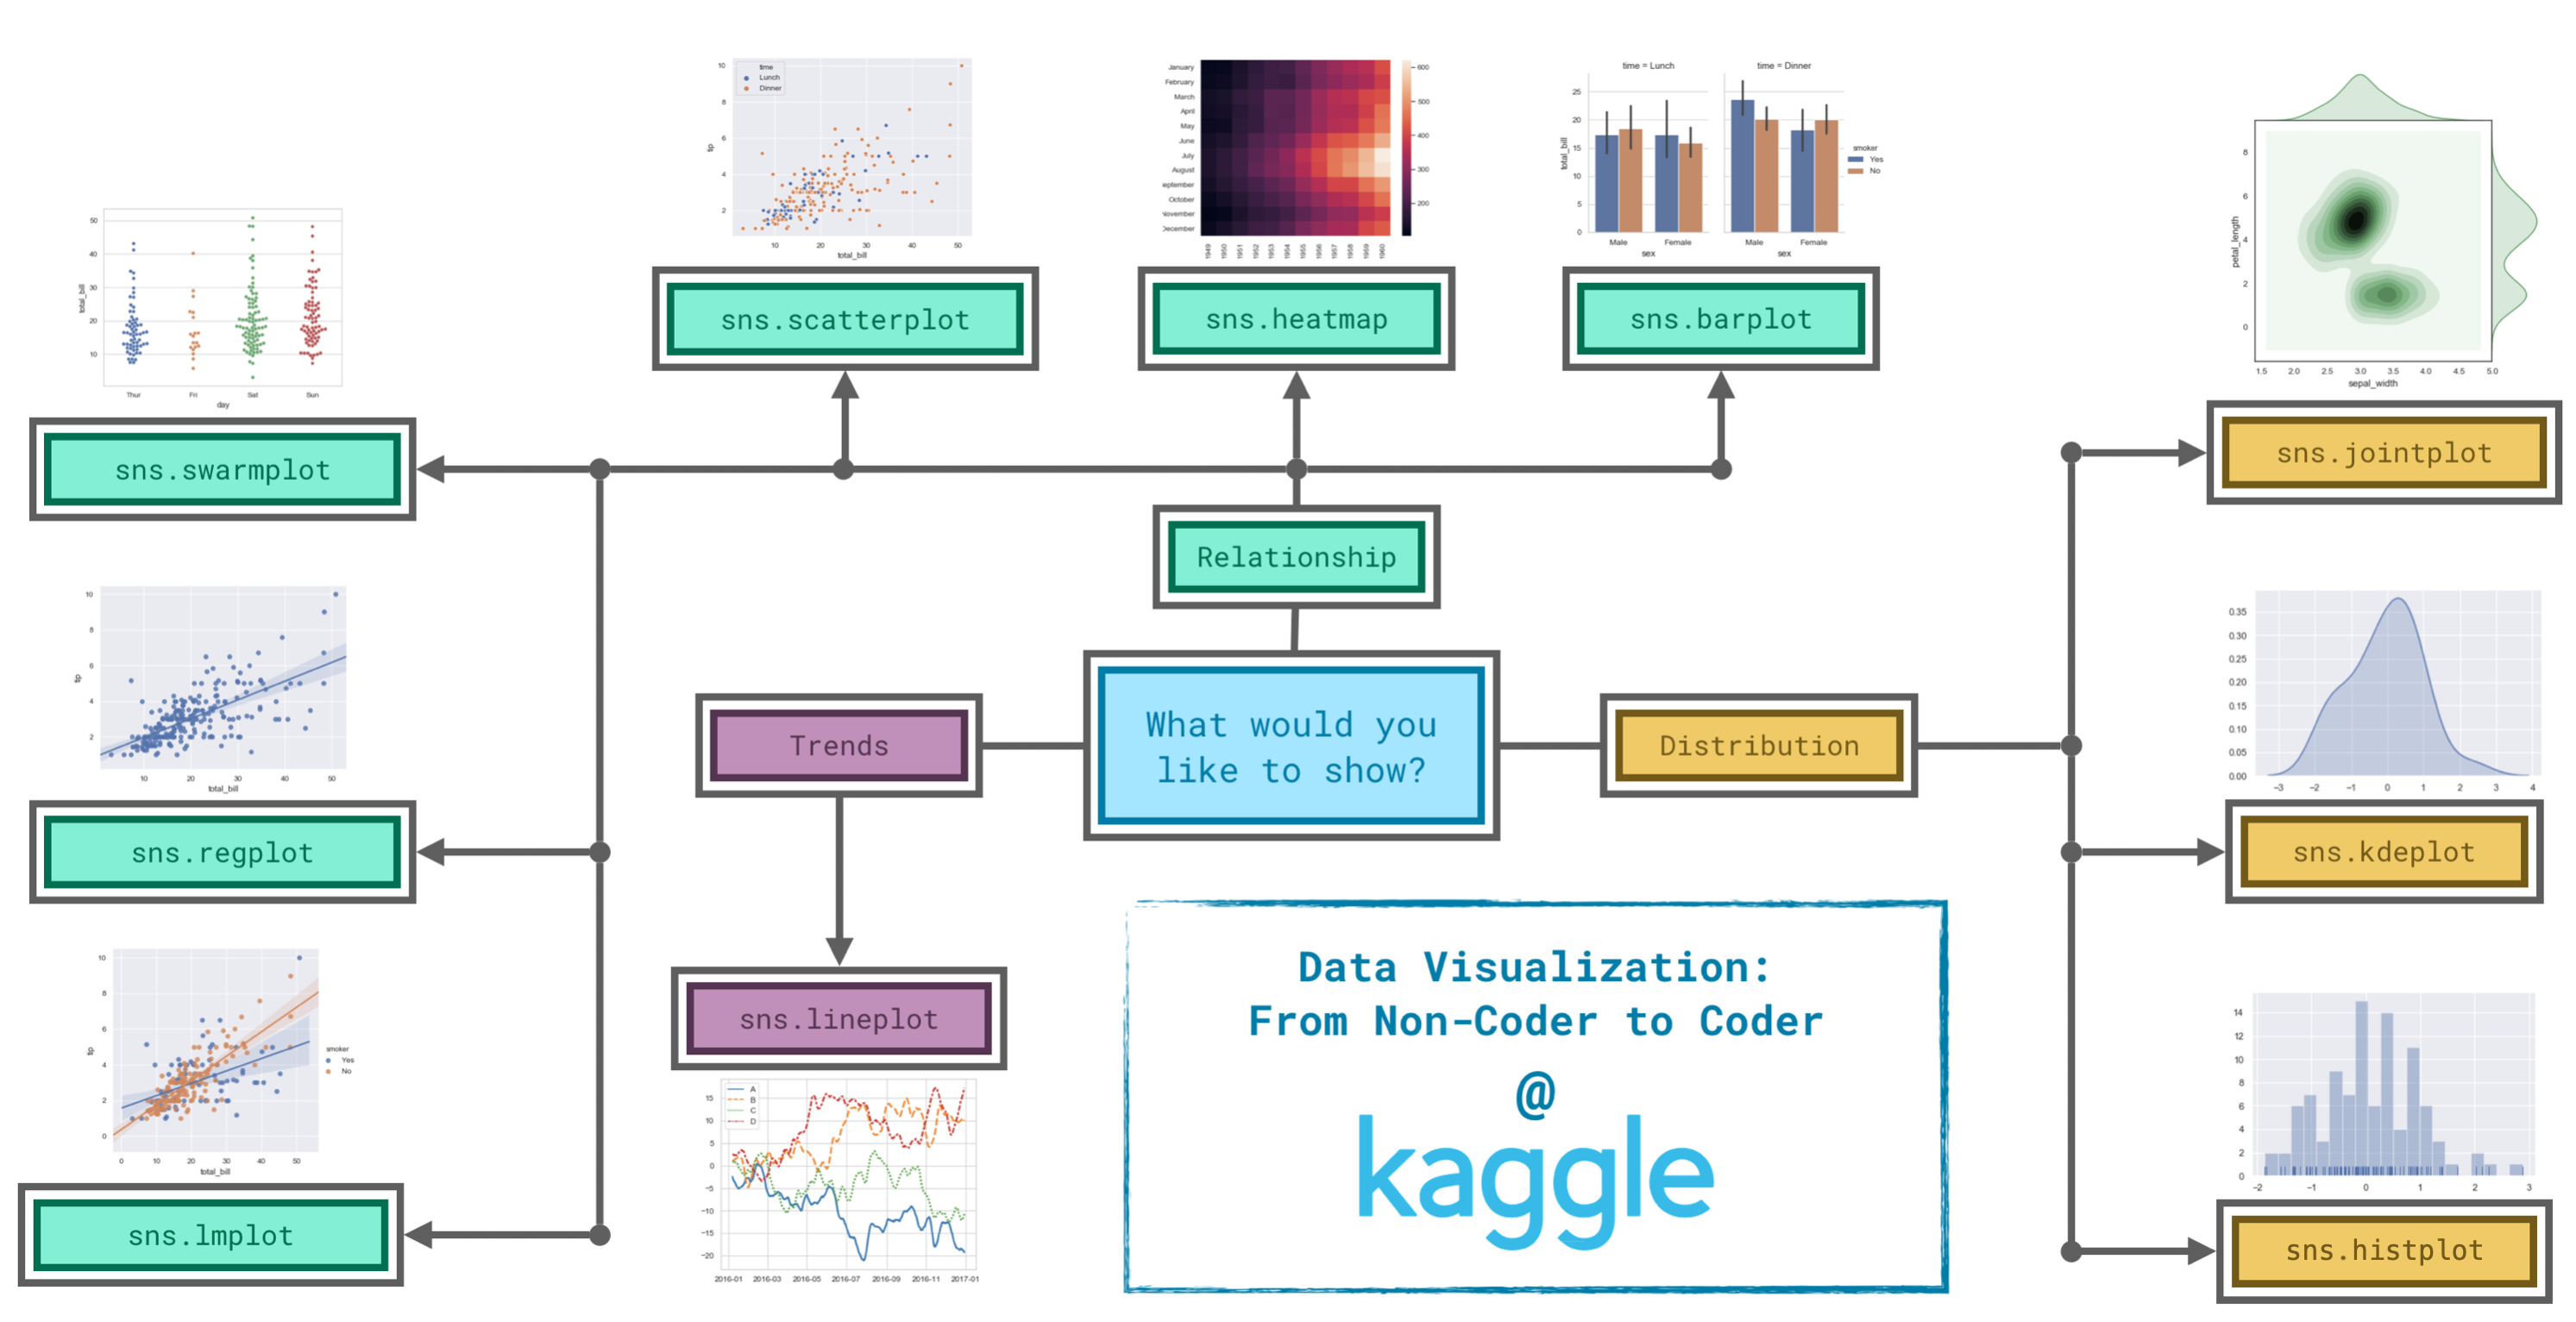

# MACHINE LEARNING 

## Concepts and Model of ML
### `Linear regression` <br>
A type of machine learning model in which both of the following are true:

The model is a linear model.
The prediction is a floating-point value. (This is the regression part of linear regression.)


Linear regression is a statistical technique used to find the relationship between variables. In an ML context, linear regression finds the relationship between features and a label.

For example, suppose we want to predict a car's fuel efficiency in miles per gallon based on how heavy the car is, and we have the following dataset:

### `Decision Tree`
There are fancier models that give more accurate predictions. But decision trees are easy to understand, and they are the basic building block for some of the best models in data science.

It divides houses into only two categories. The predicted price for any house under consideration is the historical average price of houses in the same category.

We use data to decide how to break the houses into two groups, and then again to determine the predicted price in each group. This step of capturing patterns from data is called fitting or training the model. The data used to fit the model is called the training data.
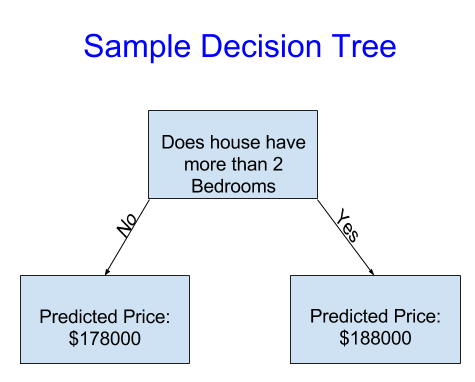

#### Improving the Decision Tree
Which of the following two decision trees is more likely to result from fitting the real estate training data?


The decision tree on the left (Decision Tree 1) probably makes more sense, because it captures the reality that houses with more bedrooms tend to sell at higher prices than houses with fewer bedrooms. The biggest shortcoming of this model is that it doesn't capture most factors affecting home price, like number of bathrooms, lot size, location, etc.

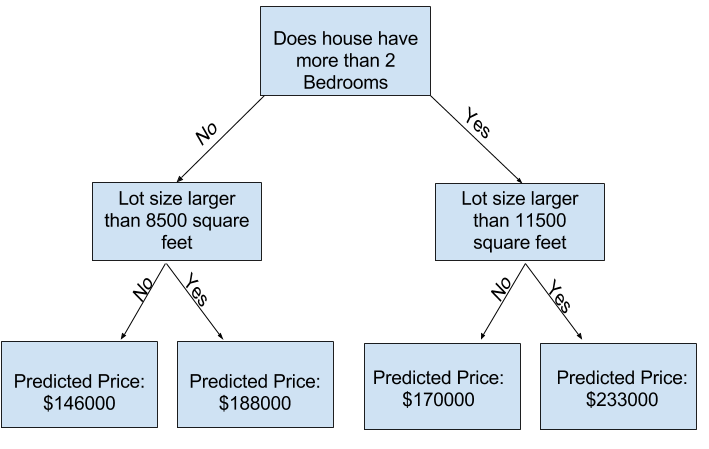

You can capture more factors using a tree that has more "splits." These are called "deeper" trees. A decision tree that also considers the total size of each house's lot might look like this:Depth 2 Tree

You predict the price of any house by tracing through the decision tree, always picking the path corresponding to that house's characteristics. The predicted price for the house is at the bottom of the tree. The point at the bottom where we make a prediction is called a leaf.
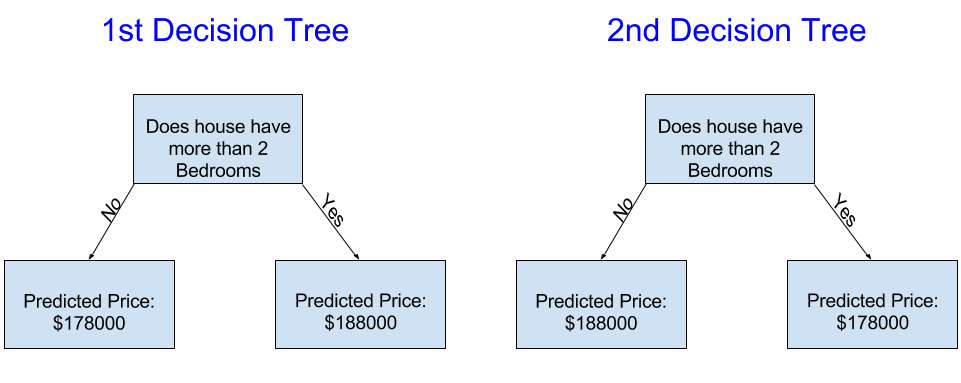

In [1]:
import pandas as pd

melbourne_file_path = 'melb_data.csv'
melbourne_data = pd.read_csv(melbourne_file_path) 
melbourne_data.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [2]:

# dropna drops missing values (think of na as "not available")
melbourne_data = melbourne_data.dropna(axis=0)

In [3]:
y = melbourne_data.Price

In [5]:

melbourne_features = ['Rooms', 'Bathroom', 'Landsize', 'Lattitude', 'Longtitude']
x = melbourne_data[melbourne_features]

In [6]:
x.describe()

,Rooms,Bathroom,Landsize,Lattitude,Longtitude
count,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000
mean,2.931407,1.576340,471.006940,-37.807904,144.990201
std,0.971079,0.711362,897.449881,0.075850,0.099165
min,1.000000,1.000000,0.000000,-38.164920,144.542370
25%,2.000000,1.000000,152.000000,-37.855438,144.926198
50%,3.000000,1.000000,373.000000,-37.802250,144.995800
75%,4.000000,2.000000,628.000000,-37.758200,145.052700
max,8.000000,8.000000,37000.000000,-37.457090,145.526350


In [8]:
x.head(5)

,Rooms,Bathroom,Landsize,Lattitude,Longtitude
1,2,1.0,156.0,-37.8079,144.9934
2,3,2.0,134.0,-37.8093,144.9944
4,4,1.0,120.0,-37.8072,144.9941
6,3,2.0,245.0,-37.8024,144.9993
7,2,1.0,256.0,-37.8060,144.9954


### `Building Your Model`

You will use the scikit-learn library to create your models. When coding, this library is written as sklearn, as you will see in the sample code. Scikit-learn is easily the most popular library for modeling the types of data typically stored in DataFrames.

The steps to building and using a model are:

Define: What type of model will it be? A decision tree? Some other type of model? Some other parameters of the model type are specified too.

Fit: Capture patterns from provided data. This is the heart of modeling.

Predict: Just what it sounds like

Evaluate: Determine how accurate the model's predictions are.

In [10]:
from sklearn.tree import DecisionTreeRegressor
# Create the model
# Define model. Specify a number for random_state to ensure same results each run
melbourne_model = DecisionTreeRegressor(random_state=1)

# Fit model to the training data
melbourne_model.fit(x, y)

DecisionTreeRegressor(random_state=1)

`Many machine learning models allow some randomness in model training. Specifying a number for random_state ensures you get the same results in each run. This is considered a good practice. You use any number, and model quality won't depend meaningfully on exactly what value you choose.`

In [11]:
print("Making predictions for the following 5 houses:")
print(x.head())
print("The predictions are")
print(melbourne_model.predict(x.head()))

Making predictions for the following 5 houses:
   Rooms  Bathroom  Landsize  Lattitude  Longtitude
1      2       1.0     156.0   -37.8079    144.9934
2      3       2.0     134.0   -37.8093    144.9944
4      4       1.0     120.0   -37.8072    144.9941
6      3       2.0     245.0   -37.8024    144.9993
7      2       1.0     256.0   -37.8060    144.9954
The predictions are
[1035000. 1465000. 1600000. 1876000. 1636000.]


### What is Model Validation

You'll want to evaluate almost every model you ever build. In most (though not all) applications, the relevant measure of model quality is predictive accuracy. In other words, will the model's predictions be close to what actually happens.

Many people make a huge mistake when measuring predictive accuracy. They make predictions with their training data and compare those predictions to the target values in the training data. You'll see the problem with this approach and how to solve it in a moment, but let's think about how we'd do this first.

You'd first need to summarize the model quality into an understandable way. If you compare predicted and actual home values for 10,000 houses, you'll likely find mix of good and bad predictions. Looking through a list of 10,000 predicted and actual values would be pointless. We need to summarize this into a single metric.

There are many metrics for summarizing model quality, but we'll start with one called Mean Absolute Error (also called MAE). Let's break down this metric starting with the last word, error.

The prediction error for each house is:

` error=actual−predicted `

So, if a house cost $150,000 and you predicted it would cost $100,000 the error is $50,000.

With the MAE metric, we take the absolute value of each error. This converts each error to a positive number. We then take the average of those absolute errors. This is our measure of model quality. In plain English, it can be said as

On average, our predictions are off by about X.

To calculate MAE, we first need a model. 

Once we have a model, here is how we calculate the mean absolute error:




In [14]:
from sklearn.metrics import mean_absolute_error
# Get predicted prices on the training data 
predicted_home_prices = melbourne_model.predict(x)
# Calculate mean absolute error between predicted and actual prices 
mae = mean_absolute_error(y, predicted_home_prices)
mae

1115.7467183128902

In [16]:
from sklearn.model_selection import train_test_split
# Split data into training and validation sets
# split data into training and validation data, for both features and target
# The split is based on a random number generator. Supplying a numeric value to
# the random_state argument guarantees we get the same split every time we
# run this script.
train_x, val_x, train_y, val_y = train_test_split(x, y, random_state=0)

# Fit the model using the training data
melbourne_model.fit(train_x, train_y)
# Get predicted prices on the validation data
predicted_home_prices = melbourne_model.predict(val_x)  
# Calculate mean absolute error between predicted and actual prices
mae = mean_absolute_error(val_y, predicted_home_prices)
mae

273518.01872175594

This is a phenomenon called `overfitting`, where a model matches the training data almost perfectly, but does poorly in validation and other new data. On the flip side, if we make our tree very shallow, it doesn't divide up the houses into very distinct groups.

At an extreme, if a tree divides houses into only 2 or 4, each group still has a wide variety of houses. Resulting predictions may be far off for most houses, even in the training data (and it will be bad in validation too for the same reason). When a model fails to capture important distinctions and patterns in the data, so it performs poorly even in training data, that is called underfitting.

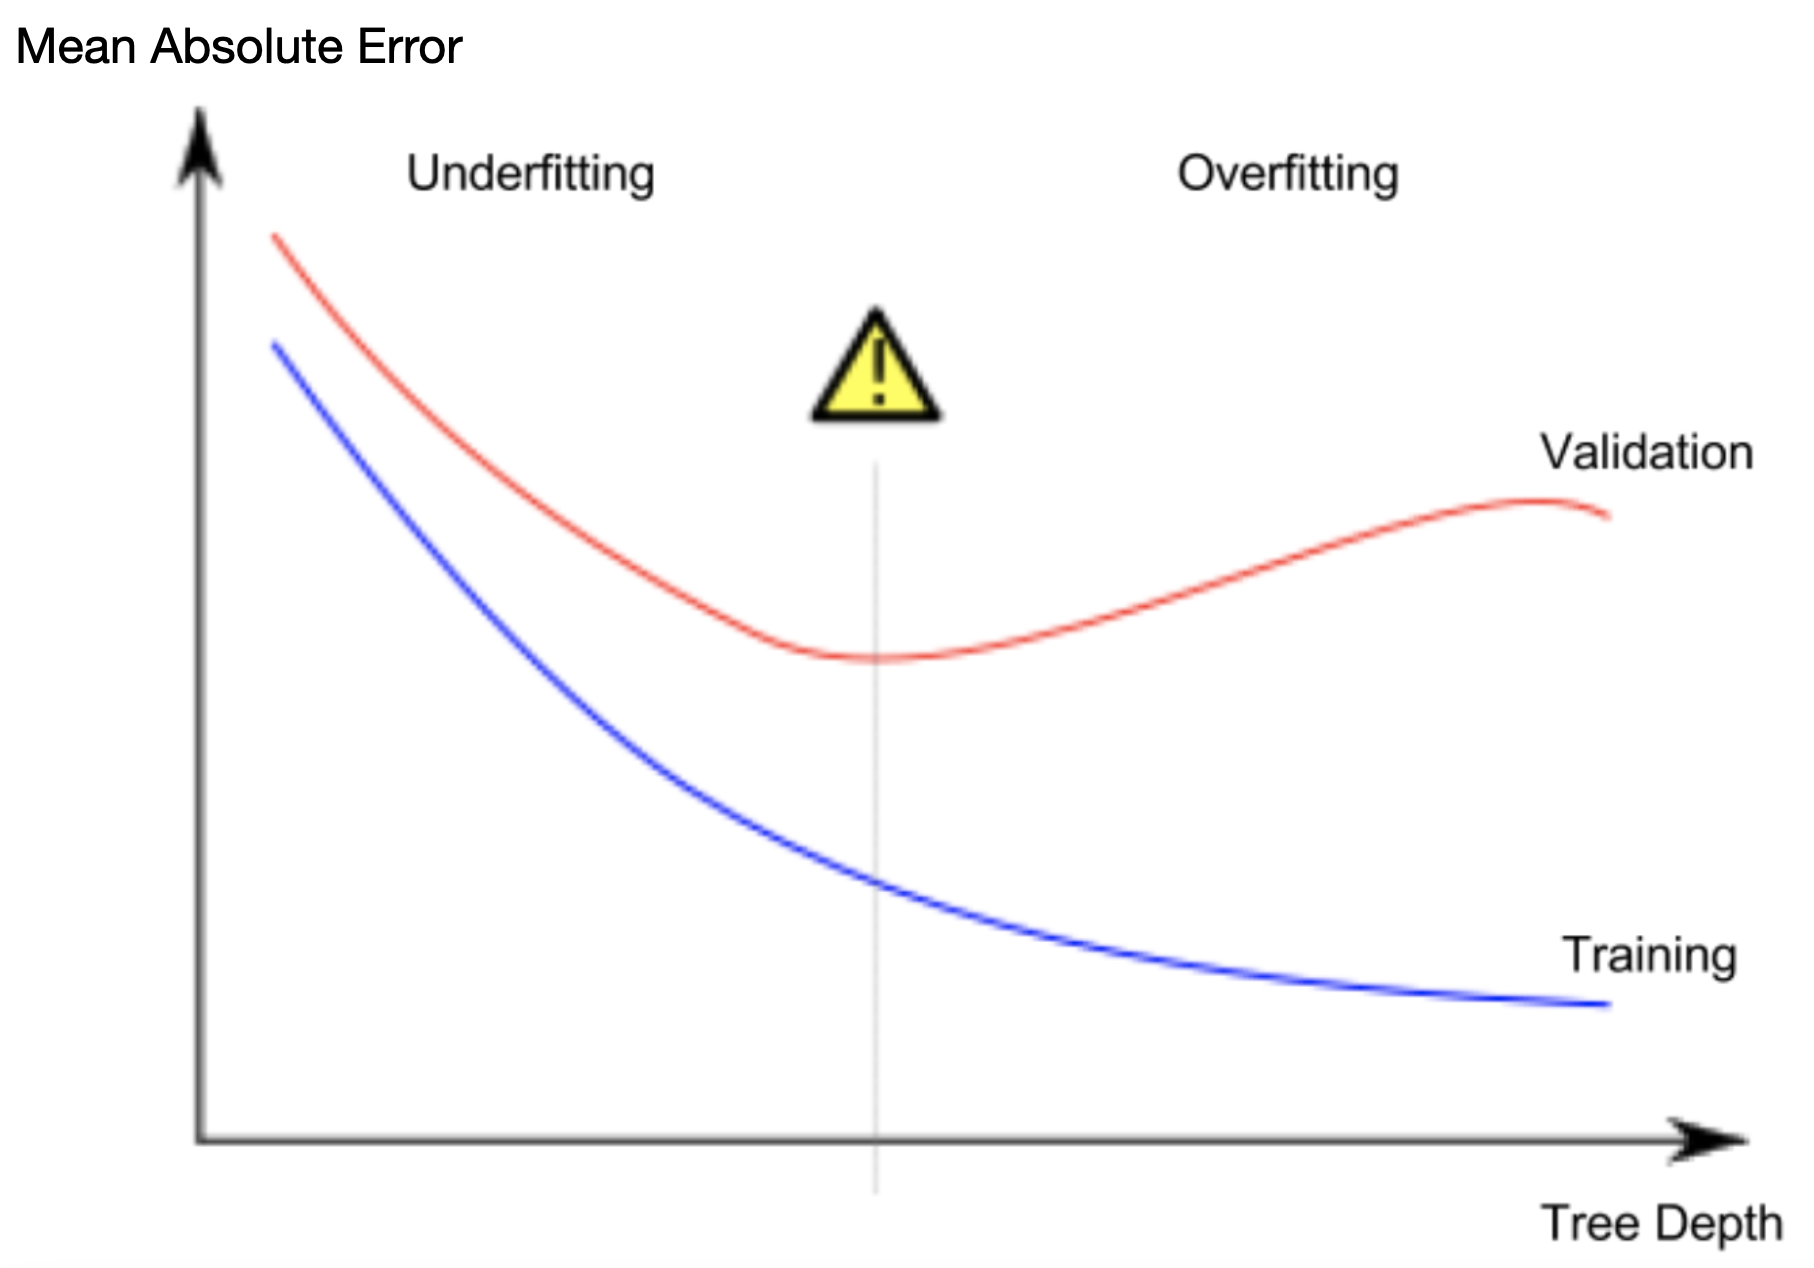

#### Example

There are a few alternatives for controlling the tree depth, and many allow for some routes through the tree to have greater depth than other routes. But the max_leaf_nodes argument provides a very sensible way to control overfitting vs underfitting. The more leaves we allow the model to make, the more we move from the underfitting area in the above graph to the overfitting area.

We can use a utility function to help compare MAE scores from different values for max_leaf_nodes:

In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

def get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y):
    model = DecisionTreeRegressor(max_leaf_nodes=max_leaf_nodes, random_state=0)
    model.fit(train_X, train_y)
    preds_val = model.predict(val_X)
    mae = mean_absolute_error(val_y, preds_val)
    return(mae)

We can use a for-loop to compare the accuracy of models built with different values for max_leaf_nodes.

In [18]:
# compare MAE with differing values of max_leaf_nodes
for max_leaf_nodes in [5, 50, 500, 5000]:
    my_mae = get_mae(max_leaf_nodes, train_x, val_x, train_y, val_y)
    print("Max leaf nodes: %d  \t\t Mean Absolute Error:  %d" %(max_leaf_nodes, my_mae))

Max leaf nodes: 5  		 Mean Absolute Error:  385696
Max leaf nodes: 50  		 Mean Absolute Error:  279794
Max leaf nodes: 500  		 Mean Absolute Error:  261718
Max leaf nodes: 5000  		 Mean Absolute Error:  271320


`Overfitting:` capturing spurious patterns that won't recur in the future, leading to less accurate predictions, or

`Underfitting:` failing to capture relevant patterns, again leading to less accurate predictions.

We use validation data, which isn't used in model training, to measure a candidate model's accuracy.

### Random Forest

The random forest uses many trees, and it makes a prediction by averaging the predictions of each component tree. It generally has much better predictive accuracy than a single decision tree and it works well with default parameters. If you keep modeling, you can learn more models with even better performance, but many of those are sensitive to getting the right parameters.

We build a random forest model similarly to how we built a decision tree in scikit-learn - this time using the `RandomForestRegressor` class instead of `DecisionTreeRegressor`.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

forest_model = RandomForestRegressor(random_state=1)
forest_model.fit(train_x, train_y)
melb_preds = forest_model.predict(val_x)
print(mean_absolute_error(val_y, melb_preds))

207190.6873773146
